# Agentic AI - Chart Generation

**Source:** [DeepLearning.AI - Agentic AI Course](https://www.deeplearning.ai/courses/agentic-ai/)  
**Modified by:** [Alireza Akhavan](https://github.com/Alireza-Akhavan/Agentic_AI)

## 1. Lab overview

You will implement the **reflection pattern** introduced in the lecture video within an agentic workflow that generates data visualizations. A multi-modal LLM will review the first draft chart, identify potential improvements—such as chart type, labels, or color choices—and then rewrite the chart generation code to produce a more effective visualization.

The steps that the workflow will carry out are:

1. **Generate an initial version (V1):**
Use a Large Language Model (LLM) to create the first version of the plotting code.

2. **Execute code and create chart:**
Run the generated code and display the resulting chart. ** (check everywhere)

3. **Reflect on the output:**
Evaluate both the code and the chart using an LLM to detect areas for improvement (e.g., clarity, accuracy, design).

4. **Generate and execute improved version (V2):**
Produce a refined version of the plotting code based on reflection insights and render the enhanced chart.



## 2. Setup: Initialize environment and client

In this step, you load your API keys and import the key libraries that will support the workflow:  

- **`load_dotenv`** (from `python-dotenv`): loads your API keys (e.g. `OPENAI_API_KEY`, `ANTHROPIC_API_KEY`) from a local `.env` file into environment variables. This is the very first code cell of the notebook.
- **`init_chat_model`** (from `langchain`): one provider-agnostic way to create a chat model from a `"provider:model"` string such as `"openai:gpt-4o-mini"` or `"anthropic:claude-sonnet-5"`.
- **`HumanMessage`** (from `langchain`): lets you build a multimodal message that contains both text and an image.
- **`pydantic`**: used to declare the *shape* of the LLM answers (e.g. a `code` field, or `feedback` + `refined_code`). LangChain’s `with_structured_output` fills these schemas, so no manual parsing is needed.
- **`llm_helpers`**: A custom helper module provided for this lab. It includes utility functions to work with the dataset, encode images, and display results in a clean, readable format.  

> 💡 Create a file named `.env` next to this notebook and put your keys in it:
> ```
> OPENAI_API_KEY=sk-...
> ANTHROPIC_API_KEY=...        # only needed if you use Anthropic models
> ```


In [1]:
from dotenv import load_dotenv

# Load API keys (OPENAI_API_KEY, ANTHROPIC_API_KEY, ...) from the local .env file
_ = load_dotenv()

In [2]:
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

# Local helper module
from utils import llm_helpers as utils

### 2.1. Loading the dataset

Let’s take a look at the coffee sales data to see what information is contained in the file.

In [5]:
# Use this utils.py function to load the data into a dataframe
df = utils.load_and_prepare_data('data/coffee_sales.csv')

# Grab a random sample to display
utils.print_html(df.sample(n=5), title="Random Sample of Coffee Sales Data")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-11-09,16:36,card,ANON-0000-0000-0876,3.576,Latte,4,11,2024
2024-11-08,17:28,card,ANON-0000-0000-0872,3.576,Hot Chocolate,4,11,2024
2024-07-03,15:17,card,ANON-0000-0000-0345,2.302,Espresso,3,7,2024
2025-01-08,13:23,card,ANON-0000-0000-1034,2.596,Cortado,1,1,2025
2024-10-18,08:05,card,ANON-0000-0000-0780,3.576,Cappuccino,4,10,2024


You’ll build an agentic workflow that generates data visualizations from this dataset, helping you answer questions about coffee sales from the vending machine.

## 3. Building the pipeline

### 3.1 Step 1 — Generate Code to Create a Chart (V1)

In this step, you’ll prompt an LLM to write Python code that generates a chart in response to a user query about the coffee dataset. The dataset includes fields such as `date`, `coffee_type`, `quantity`, and `revenue`, and you will pass this schema into the LLM so it knows what data is available.  

The question you’ll ask the model is the same one used in the lecture:  
**“Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.”**

The LLM’s output will be Python code using the **matplotlib** library. Instead of asking for free text and parsing it afterwards, we use LangChain’s **structured output**: `with_structured_output(ChartCode)` makes the model fill a small **Pydantic** schema with a single `code` field, so the code comes back clean and ready to run in the next step.


In [7]:
class ChartCode(BaseModel):
    """Python code that builds and saves a chart."""
    code: str = Field(description="Complete, valid Python code including all imports")


def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
    """Generate Python code to make a plot with matplotlib."""

    prompt = f"""
    You are a data visualization expert.

    Write code that creates a visualization from a DataFrame 'df' with these columns:
    - date (M/D/YY)
    - time (HH:MM)
    - cash_type (card or cash)
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (1-4)
    - month (1-12)
    - year (YYYY)

    User instruction: {instruction}

    Requirements for the code:
    1. Assume the DataFrame is already loaded as 'df'.
    2. Use matplotlib for plotting.
    3. Add clear title, axis labels, and legend if needed.
    4. Save the figure as '{out_path_v1}' with dpi=300.
    5. Do not call plt.show().
    6. Close all plots with plt.close().
    7. Add all necessary import python statements
    """

    llm = init_chat_model(model).with_structured_output(ChartCode)
    return llm.invoke(prompt).code

Now, try out the function and analyze the response!

In [9]:
# Generate initial code
code_v1 = generate_chart_code(
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    model="openai:gpt-4o-mini",
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM output with first draft code")

Great! You've generated some python code to create a chart!

Thanks to structured output, `code_v1` contains only the Python code — no extra text, markdown fences or tags to strip away.

### 3.2. Step 2 — Execute Code and Create Chart

In this step, you’ll run the Python code that the LLM generated in the previous step to produce the **first draft chart**.  

Here's how it works:

1. **Execute the code:**
   The code is run in a predefined global context where the DataFrame `df` is already available. This means your code can directly use df without needing to reload the dataset.

2. **Generate the chart:**
   If the code executes successfully, it will create a chart and save it as `chart_v1.png`.

3. **View the chart in the notebook:**
   The saved chart is then displayed inline using `utils.print_html`, making it easy for you to review the results.

By completing this step, you’ll have your first draft visualization (V1) ready — a big milestone in the reflection workflow!


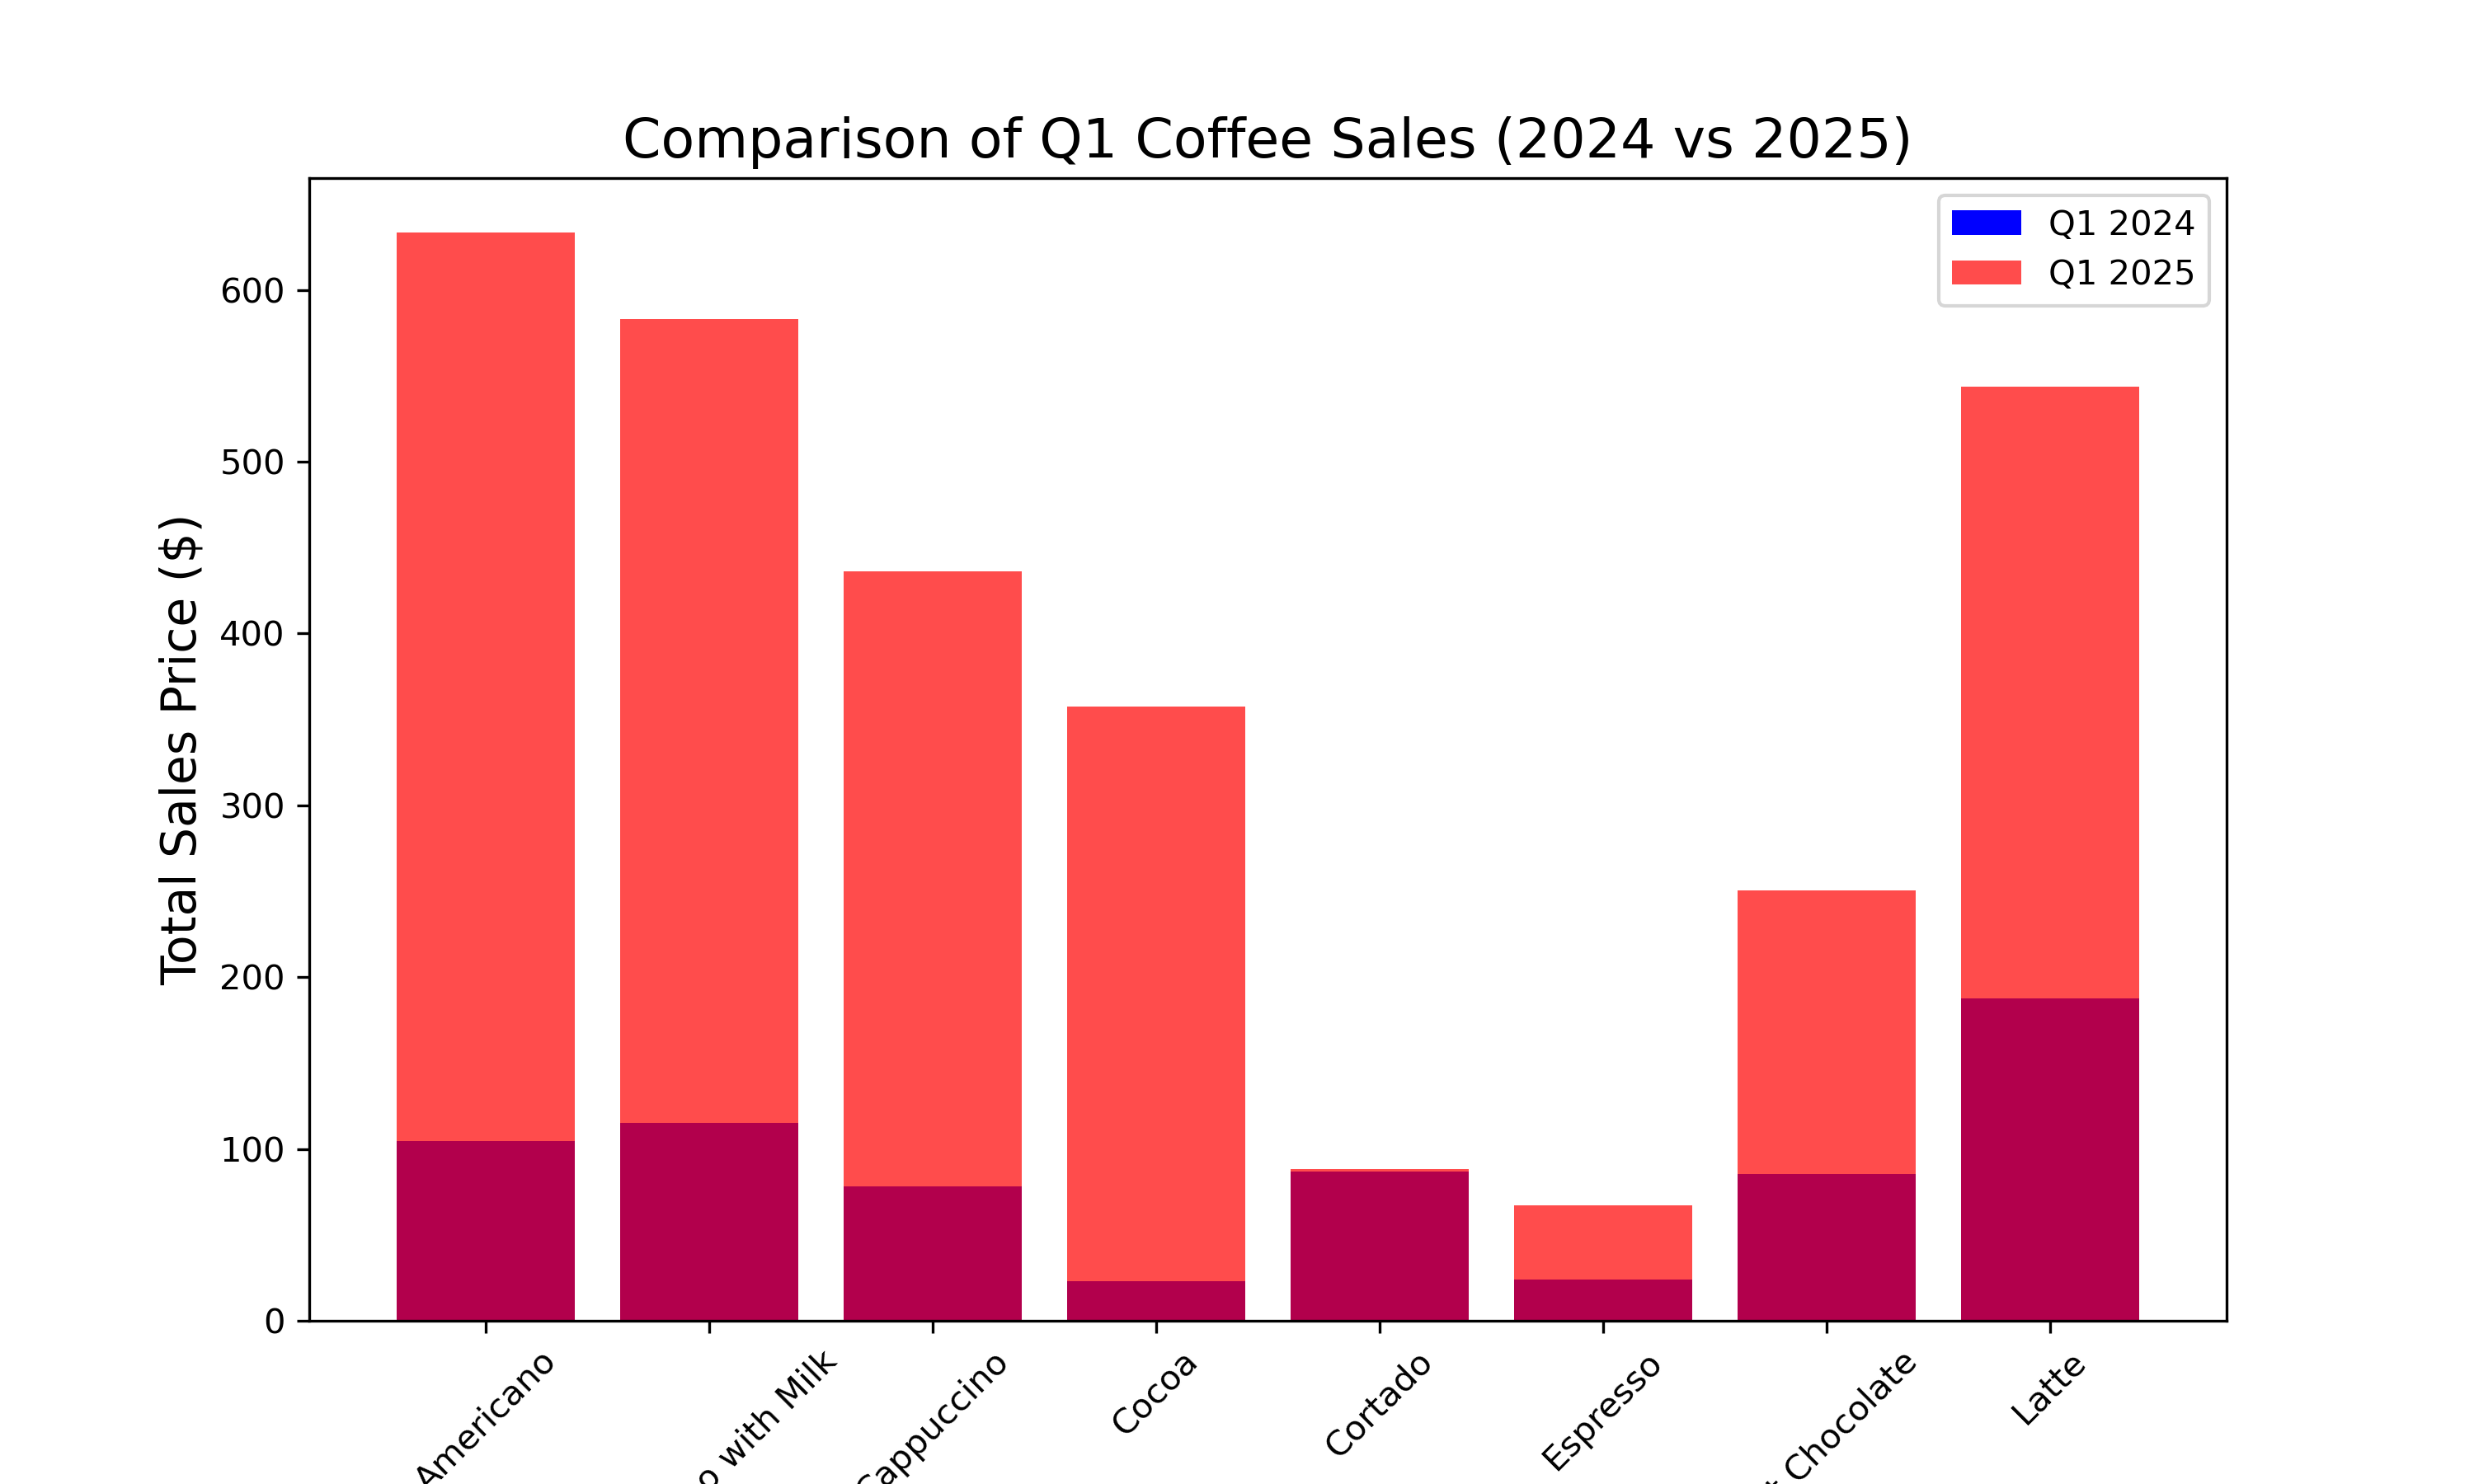

In [13]:
# Run the generated code; `df` is available to it
exec(code_v1, {"df": df})

# If code run successfully, the file chart_v1.png should have been generated
utils.print_html(
    content="chart_v1.png",
    title="Generated Chart (V1)",
    is_image=True
)

### 3.3. Step 3 — Reflect on the output

The goal here is to simulate how a human would review a first draft of a chart—looking for strengths, weaknesses, and areas for improvement.

Here’s what happens:

**1. Provide the chart to the LLM:**
The generated chart (chart_v1.png) is shared with the LLM so it can “see” the visualization.

**2. Analyze the chart visually:**
The LLM reviews elements like clarity, labeling, accuracy, and overall readability.

**3. Generate feedback:**
The LLM suggests improvements—for example, fixing axis labels, adjusting the chart type, improving color choices, or highlighting missing legends.

By doing this, you create an intelligent feedback loop where the chart is not just produced once, but actively critiqued—setting the stage for a stronger second version (V2).

In [15]:
class ChartReflection(BaseModel):
    """Critique of a chart and an improved version of its code."""
    feedback: str = Field(description="Short critique of the chart and the original code")
    refined_code: str = Field(description="Improved Python code, including all imports")


def reflect_on_image_and_regenerate(
    chart_path: str,
    instruction: str,
    model_name: str,
    out_path_v2: str,
    code_v1: str,
) -> tuple[str, str]:
    """
    Critique the chart IMAGE and the original code against the instruction,
    then return (feedback, refined_code).
    Works with any multimodal model supported by `init_chat_model`,
    e.g. "openai:o4-mini" or "anthropic:claude-sonnet-5".
    """
    media_type, b64 = utils.encode_image_b64(chart_path)

    prompt = f"""
    You are a data visualization expert.
    Your task: critique the attached chart and the original code against the given instruction,
    then write improved matplotlib code.

    Original code (for context):
    {code_v1}

    Constraints for the improved code:
    - Import all necessary libraries. Don't assume any imports from the original code.
    - Use pandas/matplotlib only (no seaborn).
    - Assume df already exists; do not read from files.
    - Save to '{out_path_v2}' with dpi=300.
    - Always call plt.close() at the end (no plt.show()).

    Schema (columns available in df):
    - date (M/D/YY)
    - time (HH:MM)
    - cash_type (card or cash)
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (1-4)
    - month (1-12)
    - year (YYYY)

    Instruction:
    {instruction}
    """

    # Multimodal message: text + image (provider-agnostic content blocks)
    message = HumanMessage(
        content=[
            {"type": "text", "text": prompt},
            {"type": "image", "base64": b64, "mime_type": media_type},
        ]
    )

    llm = init_chat_model(model_name).with_structured_output(ChartReflection)
    result = llm.invoke([message])
    return result.feedback, result.refined_code

Note that the reflection step also uses **structured output**.

- `with_structured_output(ChartReflection)` makes the model return an object with two fields, validated by Pydantic:
  - **`feedback`**: a short critique of the current chart.  
  - **`refined_code`**: an improved Python code snippet.  
- There is no need to ask for a special text format and parse it by hand (JSON lines, regex, tags).

We also include a **“constraints” section** in the prompt. These rules (e.g., use matplotlib only, save the file to a specific path, call `plt.close()` at the end) help the model generate consistent, runnable code that fits the workflow.

### 3.4 Step 4 — Generate and Execute Improved Version (V2)

In this final step, it’s time to generate and run the improved version of the chart (V2).  
After running the cell, you’ll see **both the reflection written by the LLM** (explaining what needed improvement) **and the new code it generated**. The new code will then be executed to produce the updated chart.  

In [17]:
# Generate feedback alongside reflected code
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    model_name="openai:o4-mini",
    out_path_v2="chart_v2.png",
    code_v1=code_v1,   # pass in the original code for context
)

utils.print_html(feedback, title="Feedback on V1 Chart")
utils.print_html(code_v2, title="Regenerated Code Output (V2)")

Now you’ll execute the refined code returned by the reflection step. It is run against the dataset to generate the updated chart.  

If the execution is successful, you’ll see the new image (`chart_v2.png`) displayed below as the **Regenerated Chart (V2)**.


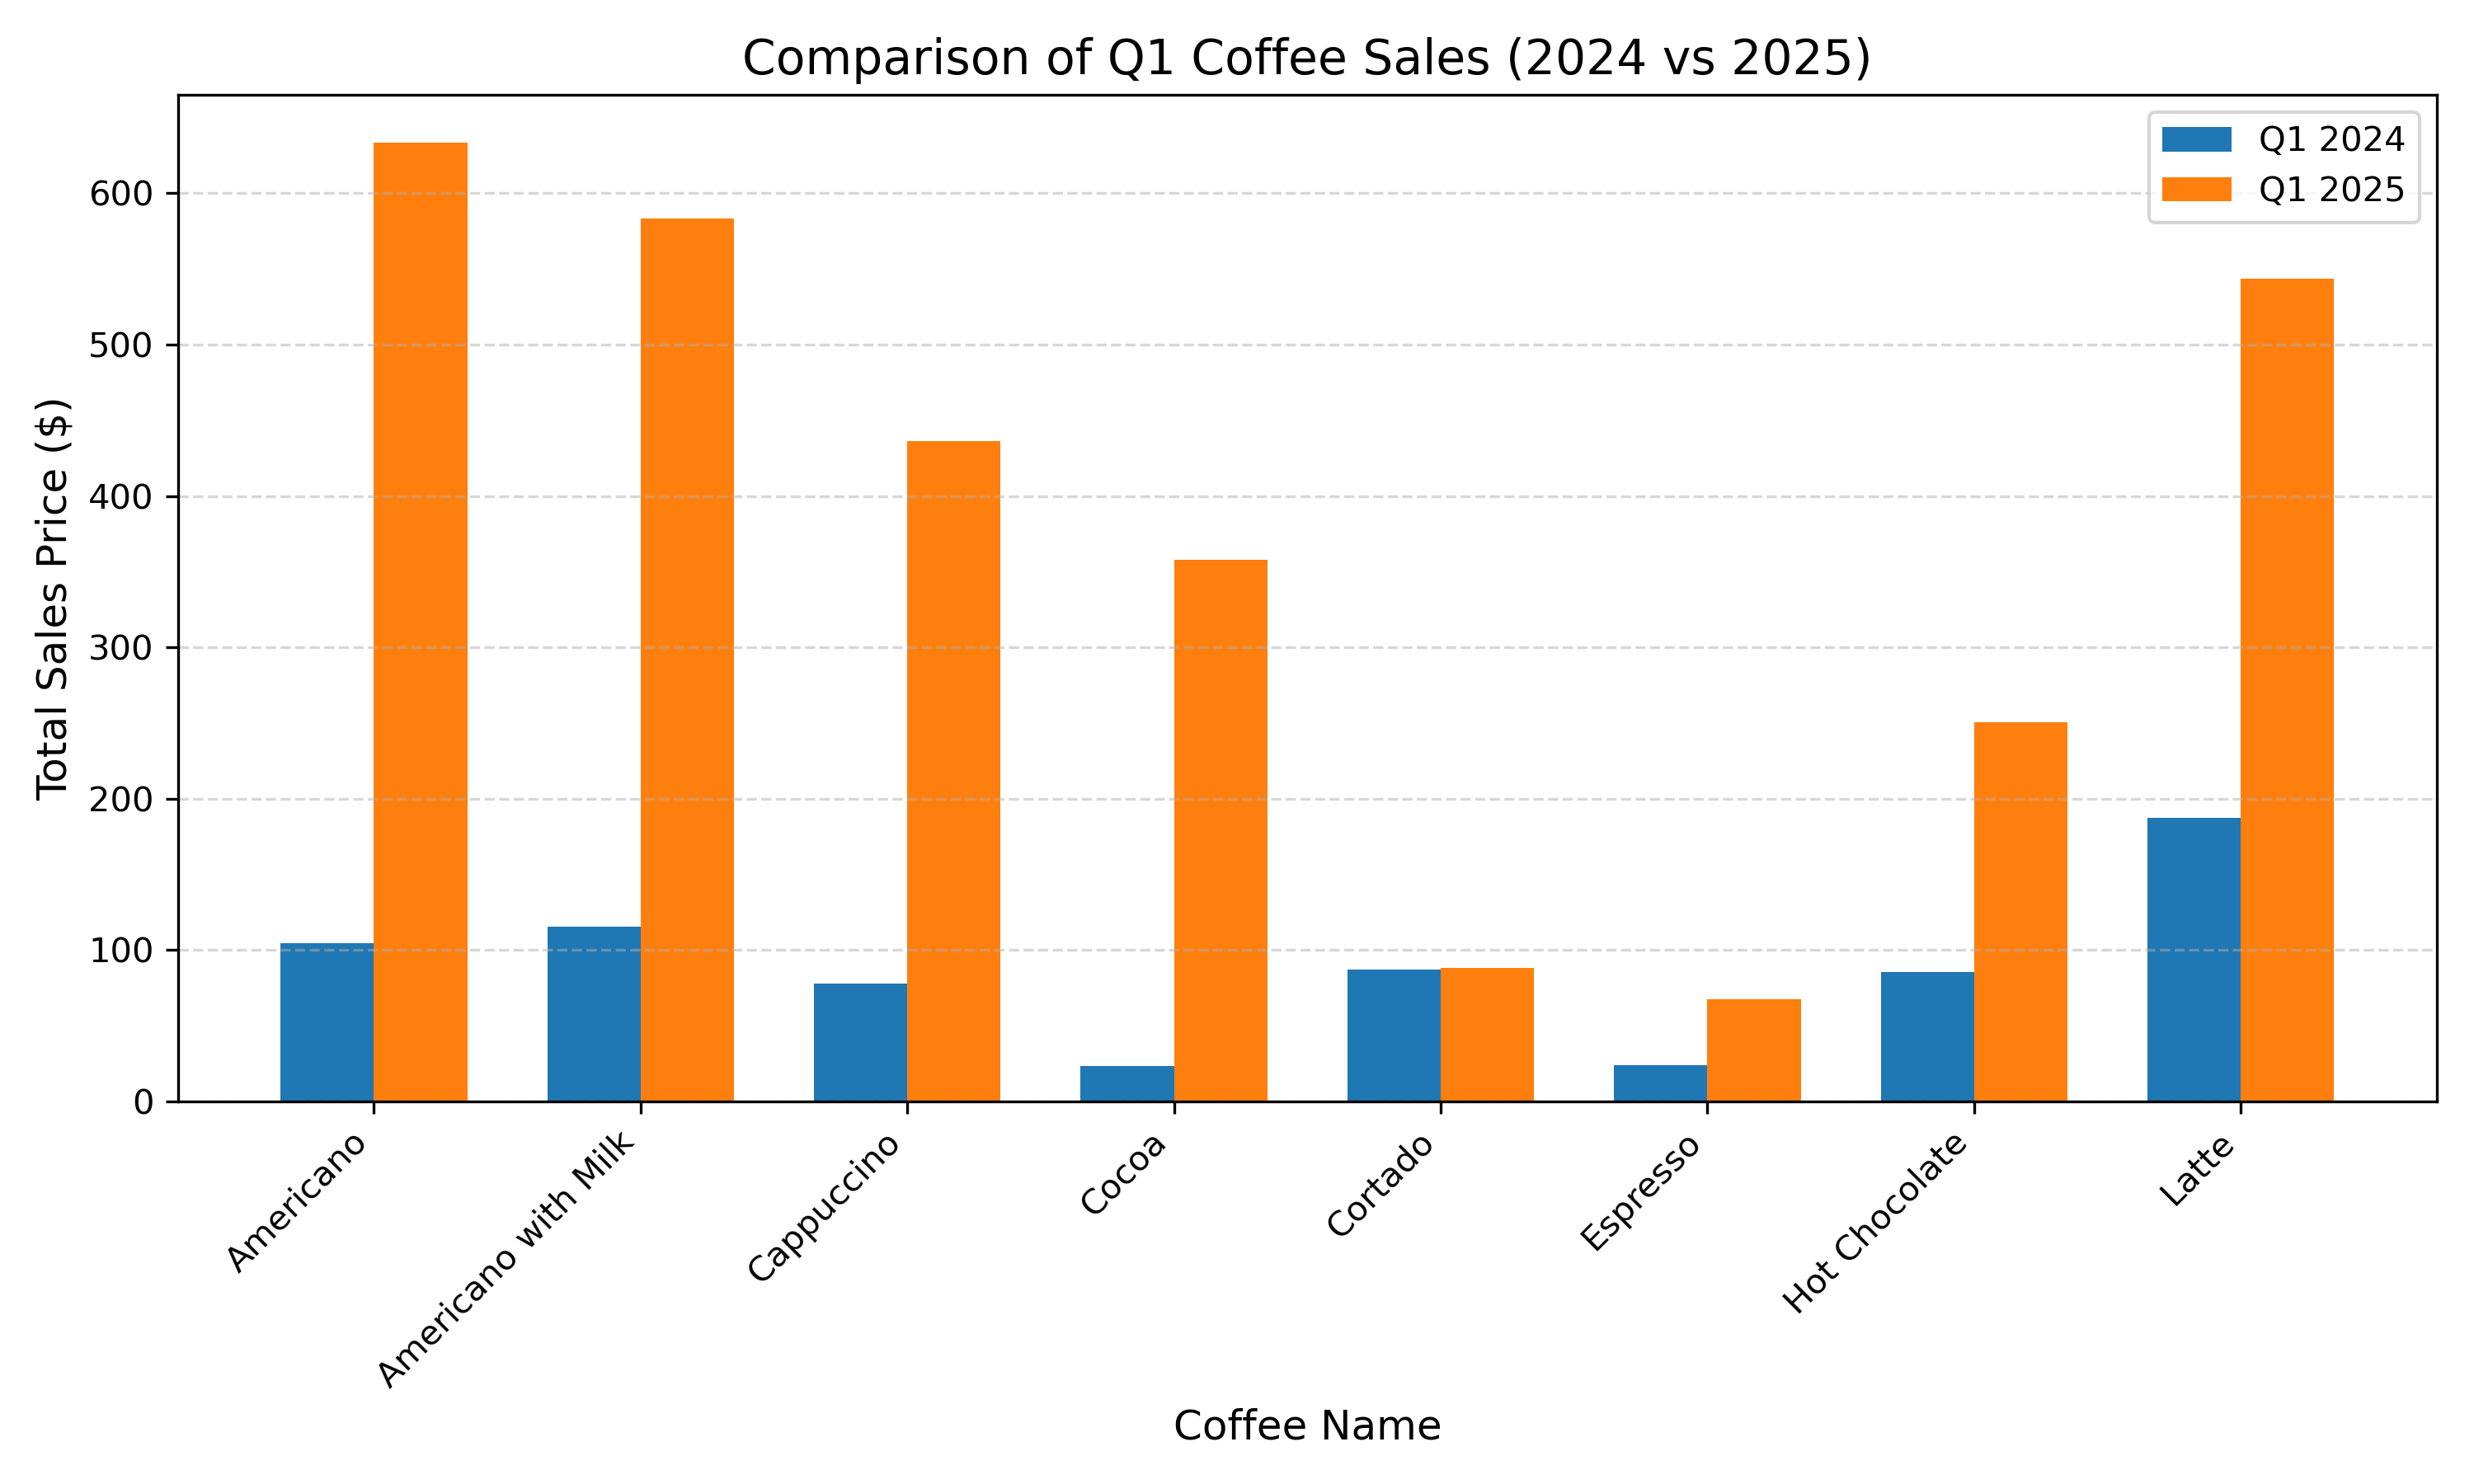

In [19]:
# Run the refined code; `df` is available to it
exec(code_v2, {"df": df})

# If code run successfully, the file chart_v2.png should have been generated
utils.print_html(
    content="chart_v2.png",
    title="Regenerated Chart (V2)",
    is_image=True
)

### 4. Put it all together — creating the end-to-end workflow

Now it’s time to wrap everything into a single automated workflow the agent can run from start to finish.

The `run_workflow` function links together the components you implemented earlier:

1) **Load and prepare data** — via `utils.load_and_prepare_data(...)`.  
2) **Generate V1 code** — with `generate_chart_code(...)`, which returns the first-draft matplotlib code.  
3) **Execute V1 immediately** — the workflow runs the generated code to produce the first chart image.  
4) **Reflect and refine** — `reflect_on_image_and_regenerate(...)` critiques the V1 image (and the original code) against the instruction, returns concise **feedback** plus **revised code (V2)**.  
5) **Execute V2 immediately** — the refined code is extracted and executed to generate the improved chart.

### What this workflow accepts
- **`dataset_path`**: location of the input CSV.  
- **`user_instructions`**: the chart request (e.g., “Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.”).  
- **`generation_model`**: model used for the initial code generation.  
- **`reflection_model`**: model used for the image-based reflection and code refinement.  
- **`image_basename`**: base filename for saving chart images (e.g., `chart_v1.png`, `chart_v2.png`).  

> Note: The chart execution steps are intentionally **hard-coded** to run right after code generation/refinement. This mirrors the workflow in the lecture and ensures you see each draft’s output before moving on.


In [ ]:
def run_workflow(
    dataset_path: str,
    user_instructions: str,
    generation_model: str,
    reflection_model: str,
    image_basename: str = "chart",
):
    """
    End-to-end pipeline:
      1) load dataset
      2) generate V1 code
      3) execute V1 → produce chart_v1.png
      4) reflect on V1 (image + original code) → feedback + refined code
      5) execute V2 → produce chart_v2.png

    Returns a dict with all artifacts (codes, feedback, image paths).
    """
    # 0) Load dataset; utils handles parsing and feature derivations (e.g., year/quarter)
    df = utils.load_and_prepare_data(dataset_path)
    utils.print_html(df.sample(n=5), title="Random Sample of Dataset")

    # Paths to store charts
    out_v1 = f"{image_basename}_v1.png"
    out_v2 = f"{image_basename}_v2.png"

    # 1) Generate code (V1)
    utils.print_html("Step 1: Generating chart code (V1)… 📈")
    code_v1 = generate_chart_code(
        instruction=user_instructions,
        model=generation_model,
        out_path_v1=out_v1,
    )
    utils.print_html(code_v1, title="LLM output with first draft code (V1)")

    # 2) Execute V1 (hard-coded: run immediately)
    utils.print_html("Step 2: Executing chart code (V1)… 💻")
    exec(code_v1, {"df": df})
    utils.print_html(out_v1, is_image=True, title="Generated Chart (V1)")

    # 3) Reflect on V1 (image + original code) to get feedback and refined code (V2)
    utils.print_html("Step 3: Reflecting on V1 (image + code) and generating improvements… 🔁")
    feedback, code_v2 = reflect_on_image_and_regenerate(
        chart_path=out_v1,
        instruction=user_instructions,
        model_name=reflection_model,
        out_path_v2=out_v2,
        code_v1=code_v1,  # pass original code for context
    )
    utils.print_html(feedback, title="Reflection feedback on V1")
    utils.print_html(code_v2, title="LLM output with revised code (V2)")

    # 4) Execute V2 (hard-coded: run immediately)
    utils.print_html("Step 4: Executing refined chart code (V2)… 🖼️")
    exec(code_v2, {"df": df})
    utils.print_html(out_v2, is_image=True, title="Regenerated Chart (V2)")

    return {
        "code_v1": code_v1,
        "chart_v1": out_v1,
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": out_v2,
    }


### 4.2. Try the workflow

Now it’s your turn to put the full workflow into action with the updated example from the lecture.

- **Instruction to use:**  
  “Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.”

When you run the workflow with this instruction, it will:
1. Generate first-draft code to create the chart.  
2. Execute that code immediately to produce the first version of the chart (V1).  
3. Reflect on the chart and the original code, producing feedback and revised code (V2).  
4. Execute the refined code to generate the improved chart (V2).  

### Customize and experiment

After trying the example above, feel free to update the `user_instructions` parameter with your own chart prompts.  
Remember to also adjust the `image_basename` so each run saves its results under a new filename — this keeps your charts organized and avoids overwriting previous outputs.

### Choosing models

Models are specified with LangChain’s `"provider:model"` string format, so you can mix and match different models (even from different providers) for generation and reflection. For example:
- Use a fast model for initial code generation (`openai:gpt-4.1-mini` or `openai:gpt-4o-mini`).  
- Use a stronger reasoning model for reflection (`openai:gpt-4.1`, `openai:o4-mini` or `anthropic:claude-sonnet-5`).  

The reflection model must be **multimodal** (able to read images). Make sure the matching API key is in your `.env` file and the provider package (`langchain-openai` / `langchain-anthropic`) is installed.

This flexibility lets you explore trade-offs between speed and quality.

👉 **Call to action:** Run the workflow now with the example instruction from the lecture. Then experiment with your own prompts to see how the agent adapts!

In [ ]:
# Here, insert your updates
user_instructions="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv." # write your instruction here
generation_model="openai:gpt-4o-mini"
reflection_model="openai:o4-mini"
image_basename="drink_sales"

# Run the complete agentic workflow
_ = run_workflow(
    dataset_path="data/coffee_sales.csv",
    user_instructions=user_instructions,
    generation_model=generation_model,
    reflection_model=reflection_model,
    image_basename=image_basename
)

## 5. Final Takeaways

In this lab, **you** practiced using reflection to improve chart outputs.
You learned to:

* Generate an initial chart (V1).
* Critique and refine it into a better version (V2).
* Automate the full workflow with different models.

The key idea: reflection helps **you** create clearer, more accurate, and more effective visualizations.


<div style="border:1px solid #22c55e; border-left:6px solid #16a34a; background:#dcfce7; border-radius:6px; padding:14px 16px; color:#064e3b; font-family:system-ui,-apple-system,Segoe UI,Roboto,Ubuntu,Cantarell,Noto Sans,sans-serif;">

🎉 <strong>Congratulations!</strong>  

You’ve completed the lab on building an **agentic chart generation workflow**.  
Along the way, **you** practiced generating charts, reflecting on their quality, and refining them into clearer and more effective visualizations.  

With these skills, **you** are ready to design agentic pipelines that create data visualizations automatically while keeping them accurate, explainable, and polished. 🌟  

</div>

